intallations


In [2]:
!pip install torch torchvision matplotlib scikit-learn transformers

imports

In [3]:
import torch
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

drive + paths

In [4]:
from google.colab import drive
drive.mount('/content/drive')

# Clone repo
!git clone https://github.com/AvitalSkop/genai-project.git
%cd genai-project

base_dir = "/content/drive/MyDrive/genai_project/data/split"

train_dir = f"{base_dir}/train"
val_dir   = f"{base_dir}/val"
test_dir  = f"{base_dir}/test"

real_test_dir = "/content/drive/MyDrive/genai_project/data/real_test"

Mounted at /content/drive
Cloning into 'genai-project'...
remote: Enumerating objects: 294, done.
remote: Counting objects: 100% (294/294), done.
remote: Compressing objects: 100% (228/228), done.
remote: Total 294 (delta 138), reused 218 (delta 65), pack-reused 0 (from 0)
Receiving objects: 100% (294/294), 3.49 MiB | 2.41 MiB/s, done.
Resolving deltas: 100% (138/138), done.
/content/genai-project


transforms

In [5]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1),
        scale=(0.8, 1.2)
    ),
    transforms.ColorJitter(
        brightness=0.5,
        contrast=0.5,
        saturation=0.3
    ),
    transforms.GaussianBlur(kernel_size=5),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

datasets

In [6]:
train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset   = datasets.ImageFolder(val_dir, transform=test_transform)
test_dataset  = datasets.ImageFolder(test_dir, transform=test_transform)

real_dataset = datasets.ImageFolder(real_test_dir, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset, batch_size=16, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=16, num_workers=0)
real_loader  = DataLoader(real_dataset, batch_size=16, num_workers=0)

print("Classes:", train_dataset.classes)

Classes: ['clean', 'empty', 'finished_leftovers', 'full']


model

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"
# model = models.resnet18(pretrained=True)
# model.fc = nn.Linear(model.fc.in_features, len(train_dataset.classes))
# model = model.to(device)
from torchvision.models import resnet18, ResNet18_Weights

model = resnet18(weights=ResNet18_Weights.DEFAULT)

# 🔥 freeze backbone
for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, len(train_dataset.classes))

model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 235MB/s]


loss + optimizer

In [8]:
# criterion = nn.CrossEntropyLoss()
from collections import Counter
import torch

labels = [label for _, label in train_dataset.samples]
class_counts = Counter(labels)

total = sum(class_counts.values())
class_weights = [total / class_counts[i] for i in range(len(class_counts))]

class_weights = torch.tensor(class_weights).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

train + eval

In [9]:
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

best_val = 0
patience = 10
counter = 0

def train_epoch(model, loader, optimizer, criterion, device):
  model.train()

  total_loss = 0
  correct = 0
  total = 0

  for i, (x, y) in enumerate(loader):
        print(f"Loaded batch {i}")
        break

  for x, y in loader:
      x, y = x.to(device), y.to(device)

      optimizer.zero_grad()

      outputs = model(x)
      # print("model ok")
      loss = criterion(outputs, y)

      loss.backward()
      optimizer.step()

      total_loss += loss.item() * x.size(0)
      preds = outputs.argmax(1)

      correct += (preds == y).sum().item()
      total += y.size(0)

  avg_loss = total_loss / total
  acc = correct / total

  return avg_loss, acc


def eval_model(model, loader, criterion, device):
  model.eval()

  total_loss = 0
  correct = 0
  total = 0

  with torch.no_grad():
      for x, y in loader:
          x, y = x.to(device), y.to(device)

          outputs = model(x)
          loss = criterion(outputs, y)

          total_loss += loss.item() * x.size(0)

          preds = outputs.argmax(1)
          correct += (preds == y).sum().item()
          total += y.size(0)

  avg_loss = total_loss / total
  acc = correct / total

  return avg_loss, acc

training

In [10]:
epochs = 30

print("Starting training...")

for epoch in range(epochs):
  train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
  val_loss, val_acc = eval_model(model, val_loader, criterion, device)

  train_losses.append(train_loss)
  train_accuracies.append(train_acc)
  val_losses.append(val_loss)
  val_accuracies.append(val_acc)

  print(f"\nEpoch {epoch+1}")
  print(f"Train Loss: {train_loss:.3f}")
  print(f"Train Acc:  {train_acc:.3f}")
  print(f"Val Loss:   {val_loss:.3f}")
  print(f"Val Acc:    {val_acc:.3f}")

  # EARLY STOPPING
  if val_acc > best_val:
      best_val = val_acc
      counter = 0
      torch.save(model.state_dict(), "best_model.pth")
      print("saved best model")
  else:
      counter += 1
      print(f"no improvement ({counter}/{patience})")

  if counter >= patience:
      print("Early stopping triggered")
      break

model.load_state_dict(torch.load("best_model.pth"))
print("Loaded best model")

Starting training...
Loaded batch 0

Epoch 1
Train Loss: 1.546
Train Acc:  0.263
Val Loss:   1.484
Val Acc:    0.227
saved best model
Loaded batch 0

Epoch 2
Train Loss: 1.462
Train Acc:  0.248
Val Loss:   1.449
Val Acc:    0.333
saved best model
Loaded batch 0

Epoch 3
Train Loss: 1.425
Train Acc:  0.226
Val Loss:   1.444
Val Acc:    0.258
no improvement (1/10)
Loaded batch 0

Epoch 4
Train Loss: 1.396
Train Acc:  0.300
Val Loss:   1.466
Val Acc:    0.227
no improvement (2/10)
Loaded batch 0

Epoch 5
Train Loss: 1.408
Train Acc:  0.256
Val Loss:   1.456
Val Acc:    0.288
no improvement (3/10)
Loaded batch 0

Epoch 6
Train Loss: 1.353
Train Acc:  0.296
Val Loss:   1.445
Val Acc:    0.288
no improvement (4/10)
Loaded batch 0

Epoch 7
Train Loss: 1.341
Train Acc:  0.344
Val Loss:   1.419
Val Acc:    0.318
no improvement (5/10)
Loaded batch 0

Epoch 8
Train Loss: 1.345
Train Acc:  0.348
Val Loss:   1.406
Val Acc:    0.318
no improvement (6/10)
Loaded batch 0

Epoch 9
Train Loss: 1.327
Tra

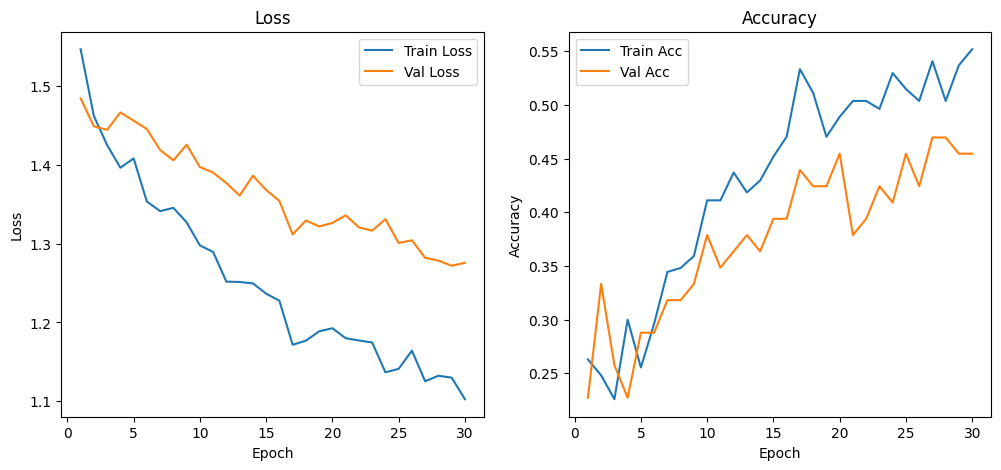

In [11]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, val_losses, label="Val Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(epochs_range, train_accuracies, label="Train Acc")
plt.plot(epochs_range, val_accuracies, label="Val Acc")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

Synthetic Test

In [12]:
synthetic_loss, synthetic_acc = eval_model(model, test_loader, criterion, device)

print(f"\nSynthetic Test Loss: {synthetic_loss:.3f}")
print(f"Synthetic Test Accuracy: {synthetic_acc:.3f}")


Synthetic Test Loss: 1.230
Synthetic Test Accuracy: 0.387


Real Test

In [ ]:
real_loss, real_acc = eval_model(model, real_loader, criterion, device)

print(f"\nReal Test Loss: {real_loss:.3f}")
print(f"Real Test Accuracy: {real_acc:.3f}")

Confusion Matrix - function

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def get_predictions(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            outputs = model(x)
            preds = outputs.argmax(1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(y.numpy())

    return np.array(all_labels), np.array(all_preds)

Synthetic CM

In [ ]:
y_true, y_pred = get_predictions(model, test_loader)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=test_dataset.classes
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Synthetic Test")
plt.show()

Real CM

In [ ]:
y_true, y_pred = get_predictions(model, real_loader)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=real_dataset.classes
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Real Test")
plt.show()

CLIP (on real data only)

In [ ]:
from transformers import CLIPProcessor, CLIPModel
from PIL import Image

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

labels_text = [
    "a perfectly clean empty plate",
    "a dirty empty plate with crumbs and stains",
    "a plate with a few leftover pieces of food",
    "a full plate with a complete meal"
]

CLIP eval

In [ ]:
def clip_predict(image):
    inputs = processor(
        text=labels_text,
        images=image,
        return_tensors="pt",
        padding=True
    ).to(device)

    outputs = clip_model(**inputs)
    probs = outputs.logits_per_image.softmax(dim=1)

    return probs.argmax().item()


def evaluate_clip(loader):
    correct = 0
    total = 0

    for x, y in loader:
        for i in range(len(x)):
            image = transforms.ToPILImage()(x[i])
            pred = clip_predict(image)

            if pred == y[i].item():
                correct += 1

            total += 1

    return correct / total


clip_acc = evaluate_clip(real_loader)

print(f"\nCLIP Accuracy (REAL DATA): {clip_acc:.3f}")

In [ ]:
!pip install nbformat

In [ ]:
import nbformat

# notebook name
notebook_path = "/content/drive/MyDrive/genai_project/code/05_train_model.ipynb"

nb = nbformat.read(notebook_path, as_version=4)

# delete widgets metadata if exist
if "widgets" in nb["metadata"]:
    del nb["metadata"]["widgets"]

# save clean file
clean_path = "/content/drive/MyDrive/genai_project/code/05_train_model_git_version.ipynb"
nbformat.write(nb, clean_path)

print("✅ Clean notebook saved:", clean_path)